In [2]:
# Set Font-Style
from IPython.display import display, HTML
display(HTML("""
<link href="https://fonts.googleapis.com/css2?family=Crimson+Pro&display=swap" rel="stylesheet">
<link href="https://cdn.jsdelivr.net/gh/dreampulse/computer-modern-web-font@master/fonts.css" rel="stylesheet">
<link href="https://fonts.googleapis.com/css2?family=Martian+Mono&display=swap" rel="stylesheet">
<style>
.jp-MarkdownOutput code {
    font-family: Consolas, monospace !important;
    font-size: 15px !important;
    background: #f5f5f5;
    padding: 1px 3px;
    border-radius: 4px;
}

.jp-MarkdownOutput pre {
    font-family: Consolas, monospace !important;
    font-size: 14px !important;
    background: #f5f5f5;
    padding: 10px;
    border-radius: 4px;
}
    .jp-MarkdownOutput p  { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput td { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput li { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.50; }
    .jp-MarkdownOutput h1 { font-family: 'Crimson Pro', serif; font-size: 32px; }
    .jp-MarkdownOutput h2 { font-family: 'Crimson Pro', serif; font-size: 26px; }
    .jp-MarkdownOutput h3 { font-family: 'Crimson Pro', serif; font-size: 22px; }
    .jp-MarkdownOutput h4 { font-family: 'Crimson Pro', serif; font-size: 18px; }
</style>
"""))

In [129]:
# Imports
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display # re-import for clarity
import time
import math
import random
import os
import numpy as np
import pandas as pd
import scipy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles

<div style="text-align: center;">
    <h1><b>AUTOENCODERS</b></h1>
    <h3>From Undercomplete Autoencoders to VAEs</h3>
</div>

--- 

## **What is an Autoencoder**
> An autoencoder is a neural network trained to reproduce its input at its output. 

Its **network** consists of two parts: an **encoder** function $h = f(x)$ and a 
**decoder** that produces a reconstruction $r = g(h)$. 

Autoencoders are not designed to copy inputs perfectly ($g(f(x)) = x$) — this would not be especially useful. <br>
Instead, they are constrained to copy only *approximately*, and because the model is forced to <br>
preserve only the useful aspects of the input, it often learns meaningful properties of the data. 

Autoencoders fall under the **Unsupervised Learning** category. 

Modern autoencoders have generalized the encoder and decoder beyond deterministic functions to **stochastic mappings**: <br>
$p_\text{encoder} (h | x)$ and $p_\text{decoder} (x | h)$

### **Usecases**
Traditionally, autoencoders were used for **dimensionality reduction** and **feature learning**. <br>
More recently, they have been adapted for generative modeling, with **Variational Autoencoders (VAEs)** <br>
being particularly influential in this space. 

### **Training**
Since autoencoders are a special case of feedforward networks, they can be trained using the same techniques — <br>
typically minibatch gradient descent with gradients computed via backpropagation. 

Autoencoders may also be trained using **recirculation**, a learning algorithm that compares network activations <br>
on the original input against activations on the reconstructed input — <br>
though this approach is rarely used in practice. 

By training on the input copying task, we hope that $h$ will capture useful structure in the data. <br>


### **Reconstruction Loss — A Probabilistic View**

Rather than treating reconstruction loss as an arbitrary penalty, we can derive it from **maximum likelihood estimation**.
The decoder defines a conditional distribution over inputs given the code:
$$p_\text{decoder}(x | h)$$

Training the autoencoder to maximize $\log p_\text{decoder}(x | h)$ recovers familiar loss functions as special cases:
- If $p_\text{decoder}(x | h) = \mathcal{N}(x; g(h), I)$ — Gaussian output — maximizing log likelihood is equivalent to minimizing **MSE**:
$$L = \| x - g(f(x)) \|^2$$

- If $p_\text{decoder}(x | h) = \text{Bernoulli}(x; g(h))$ — binary output — maximizing log likelihood gives **binary cross-entropy**:
$$L = -\sum_i x_i \log g(f(x))_i + (1 - x_i) \log(1 - g(f(x))_i)$$

The loss is not a design choice — it falls out of your assumption about the output distribution.


### **The Information Bottleneck**

The bottleneck dimension $d_h$ controls what the encoder is forced to discard.
Let $d_x$ be input dimension, $d_h$ be code dimension:

- $d_h \ll d_x$ — undercomplete, encoder must compress, forced to preserve only high-variance structure
- $d_h = d_x$ — no compression pressure, model can learn identity
- $d_h \gg d_x$ — overcomplete, must regularize or model memorizes

The useful representations live in the undercomplete regime — or the overcomplete regime <br>
with strong regularization. This tension between **capacity and constraint** is the central design question.

### **Types of Autoencoders**
#### **Undercomplete Autoencoders**
One way to encourage the autoencoder to learn useful features is to constrain $h$ to have smaller dimension than $x$.
The learning process optimizes a loss function <br>
$$ L(x, g(f(x))), $$
where **L** penalizes $g(f(x))$ for being dissimilar from $x$ — MSE being a common choice. <br>

***Note:*** when the decoder is linear and L is MSE, an undercomplete autoencoder learns to span the same subspace as **PCA**. <br>

With nonlinear encoder and decoder functions $f$ and $g$, the autoencoder can learn a more powerful generalization of PCA, <br>
but this comes at the cost of increased model capacity. <br>
As capacity grows, the autoencoder can learn to copy inputs without extracting useful information about the
underlying data distribution.

ex) an autoencoder could simply memorize training inputs by mapping each one to a unique index, <br>
rather than learning meaningful structure in the data distribution.

> This problem also occurs in **Overcomplete** autoencoders, where the code dimension is greater than the input dimension.

#### **Regularized Autoencoders**
By incorporating regularization into the loss function, regularized autoencoders maintain high model capacity <br>
while being encouraged to learn properties beyond direct input copying — <br>
with the regularization term adapting to the complexity of the input data distribution.

These learned properties include: sparsity of the representation, small derivatives of the representation, <br>
and robustness to noise or missing inputs. <br>

ex) weight decay, noise to inputs

#### **Sparse Autoencoders**
A sparse autoencoder is a ***regularized*** autoencoder that adds a **sparsity penalty** $\Omega(h)$ on the code layer $h$ to the reconstruction loss:
$$ L(x, g(f(x))) + \Omega(h), $$
where,
- $g(h)$ is the decoder output
- $h = f(x)$ is the encoder output
- $\Omega(h)$ is the regularization term

The sparsity pentalties task is the copy the input to the output (unsupervised)

Sparse autoencoders are typically used for **feature extraction** for another task, such as ***classification***. <br>


#### **Denoising Autoencoders (DAE)**

Rather than feeding clean input $x$, corrupt it first:
$$\tilde{x} \sim C(\tilde{x} | x)$$

where $C$ is a corruption process (additive Gaussian noise, masking, dropout). Train to reconstruct <br>
the clean $x$ from corrupted $\tilde{x}$:
$$L = \| x - g(f(\tilde{x})) \|^2$$

The model can no longer copy the input — it must learn the underlying data manifold to denoise successfully.

**The probabilistic interpretation (Murphy Ch 20.3):** the DAE implicitly learns to estimate:
$$\mathbb{E}[x | \tilde{x}]$$

which is the posterior mean of the clean data given the corrupted observation. The encoder learns to map <br>
off-manifold corrupted points back onto the data manifold.

> This connects directly to **score matching** and diffusion models — denoising at multiple noise scales <br>
> is precisely how modern diffusion models are trained.



### **The Manifold Hypothesis**

Why does any of this work?

Real high-dimensional data (images, terrain heightmaps, audio) does not uniformly fill $\mathbb{R}^{d_x}$. <br>
It concentrates near a **low-dimensional manifold** embedded in the high-dimensional space.

A heightmap of size $256 \times 256$ lives in $\mathbb{R}^{65536}$ — but the subset of *geologically plausible* <br>
heightmaps occupies a tiny curved surface within that space. The autoencoder's job is to find coordinates on that surface.

- The encoder $f: \mathbb{R}^{d_x} \to \mathbb{R}^{d_h}$ learns a **coordinate chart** on the manifold
- The decoder $g: \mathbb{R}^{d_h} \to \mathbb{R}^{d_x}$ learns the **embedding** back into data space

This is why latent space interpolation works — moving smoothly through $\mathbb{R}^{d_h}$ traces a path <br>
along the data manifold, producing plausible intermediate outputs.


### **From Autoencoder to VAE — The Problem**

A deterministic autoencoder gives you one code $h$ per input $x$. The latent space has no guaranteed <br>
structure — codes can cluster arbitrarily, leaving **holes** between clusters that decode to nonsense.

To generate new data you need to sample from the latent space. But where? The deterministic AE gives you no answer.

The VAE reframes the encoder as a **posterior distribution**:
$$q_\phi(h | x) = \mathcal{N}(h;\ \mu_\phi(x),\ \sigma^2_\phi(x))$$

instead of a point estimate. Training forces this posterior toward a standard Gaussian prior $p(h) = \mathcal{N}(0, I)$ <br>
via KL divergence regularization. The latent space becomes smooth, continuous, and fully sampable.

$$\mathcal{L}_\text{VAE} = \underbrace{\mathbb{E}_{q_\phi(h|x)}[\log p_\theta(x|h)]}_{\text{reconstruction}} - \underbrace{D_\text{KL}(q_\phi(h|x) \| p(h))}_{\text{regularization}}$$

This is the **ELBO** (Evidence Lower Bound) — covered in Murphy Ch 21 — and it is the natural <br>
continuation after this lab.

--- 

### **Undercomplete Autoencoder Example — 2D Gaussian Mixture**

Rather than using a real dataset, we generate a **2D Gaussian mixture** — a synthetic dataset with known 
structure that we can visualize directly and evaluate against ground truth.

A single Gaussian $\mathcal{N}(\mu, \sigma^2 I)$ produces one blob of points centered at $\mu$. <br>
A **mixture** stacks $K$ of these, each with a different center $\mu_k$:

$$x \sim \mathcal{N}(\mu_k, \sigma^2 I), \quad k \in \{1, \dots, K\}$$

Each point is sampled by picking a cluster $k$, then drawing randomly near its center:
$$x = \mu_k + \sigma \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

We use $K = 4$ clusters at $(±2, ±2)$ with $\sigma = 0.4$ — far enough apart to be visually separable, 
tight enough to be distinct blobs.

This gives us data shaped `(N, 2)` — $N$ points in 2D space, two features each.

**Why this dataset:**
- $d_x = 2$ means we can plot raw data directly — no PCA or t-SNE needed
- Known ground truth structure lets us evaluate what the encoder actually learned
- Labels $y$ are generated but **never shown to the autoencoder** — it must discover structure unsupervised
- The bottleneck sweep $d_h = 1 \to 2$ is geometrically interpretable in 2D

Using device: cuda


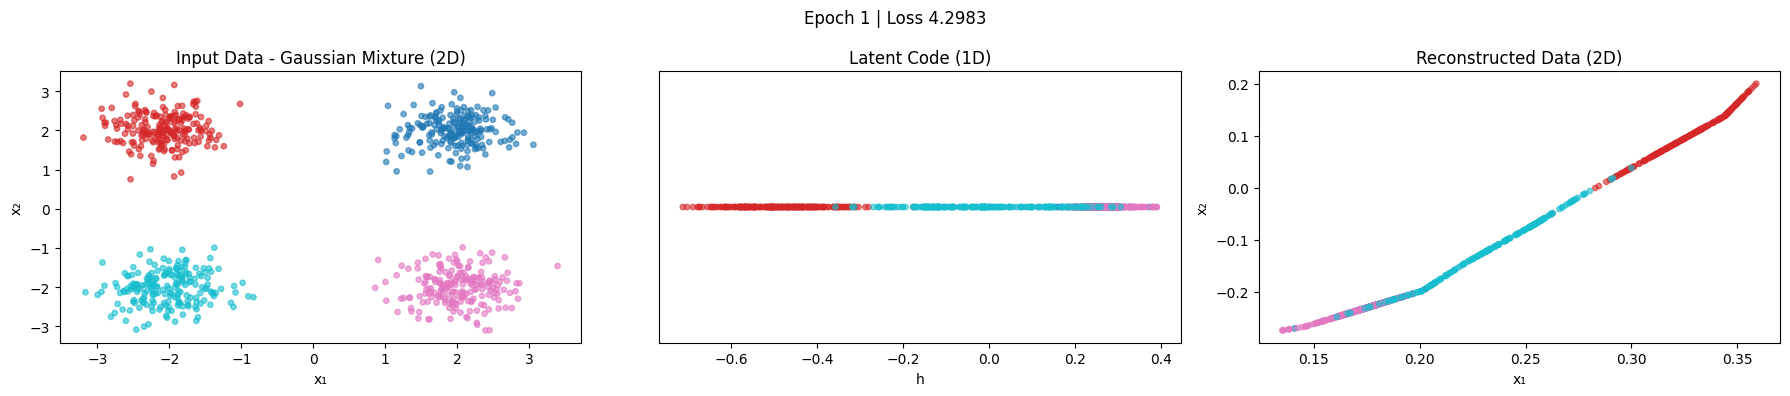

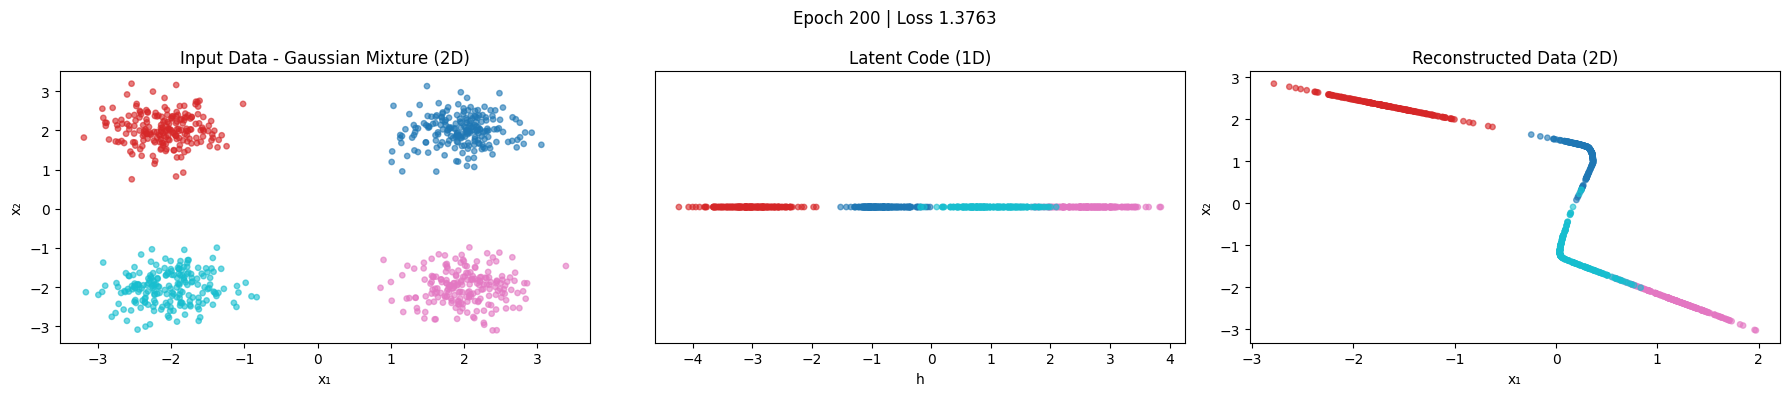

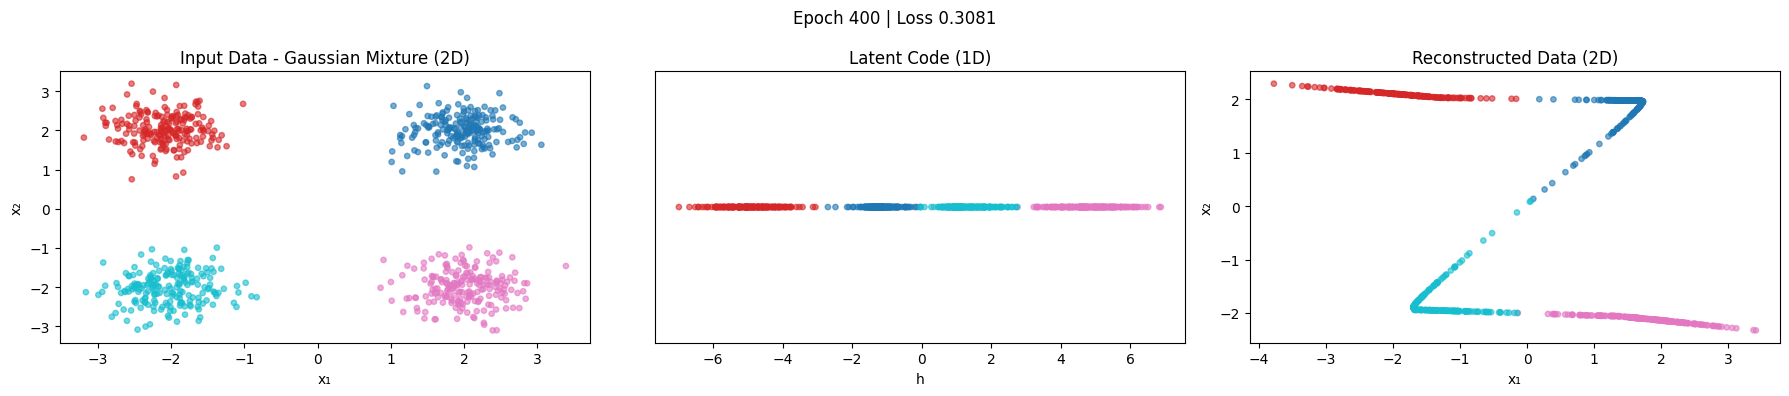

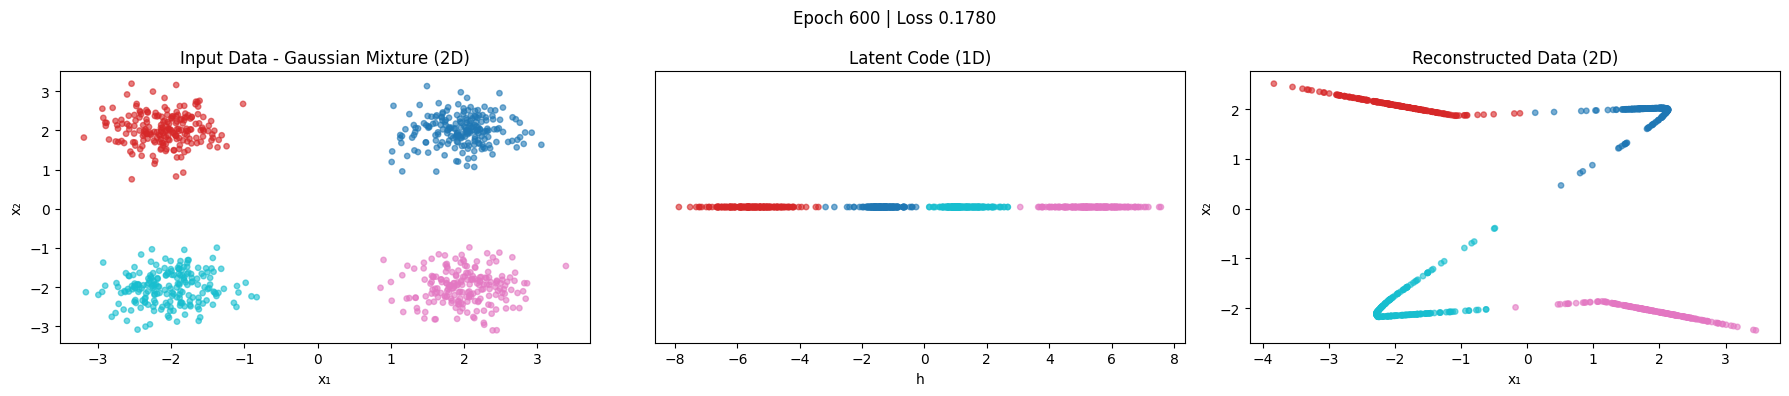

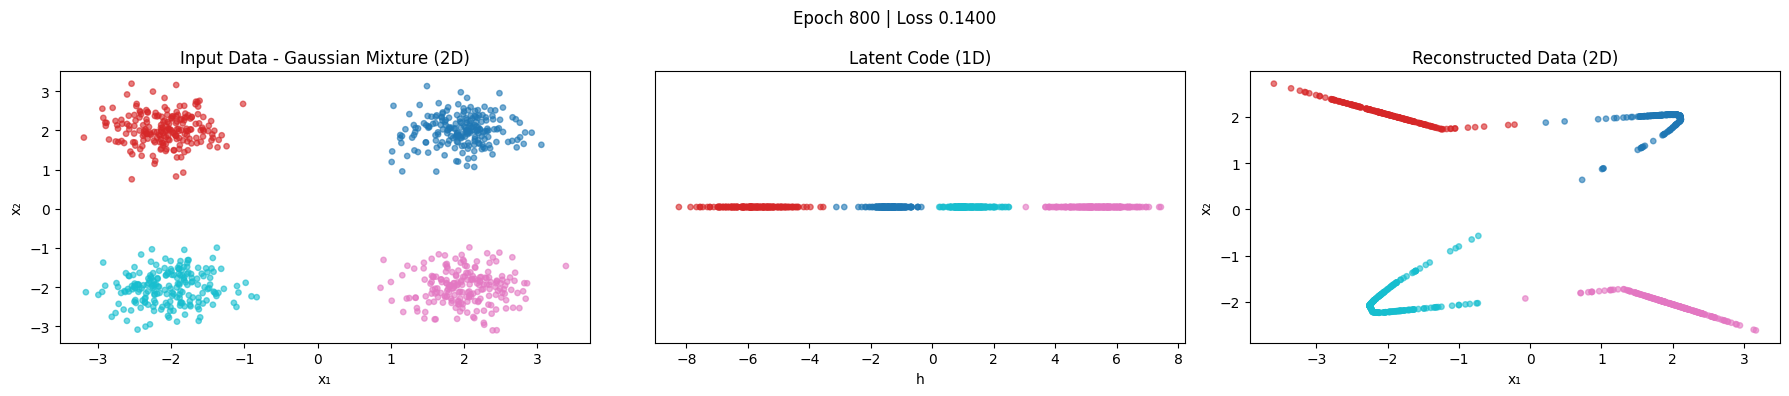

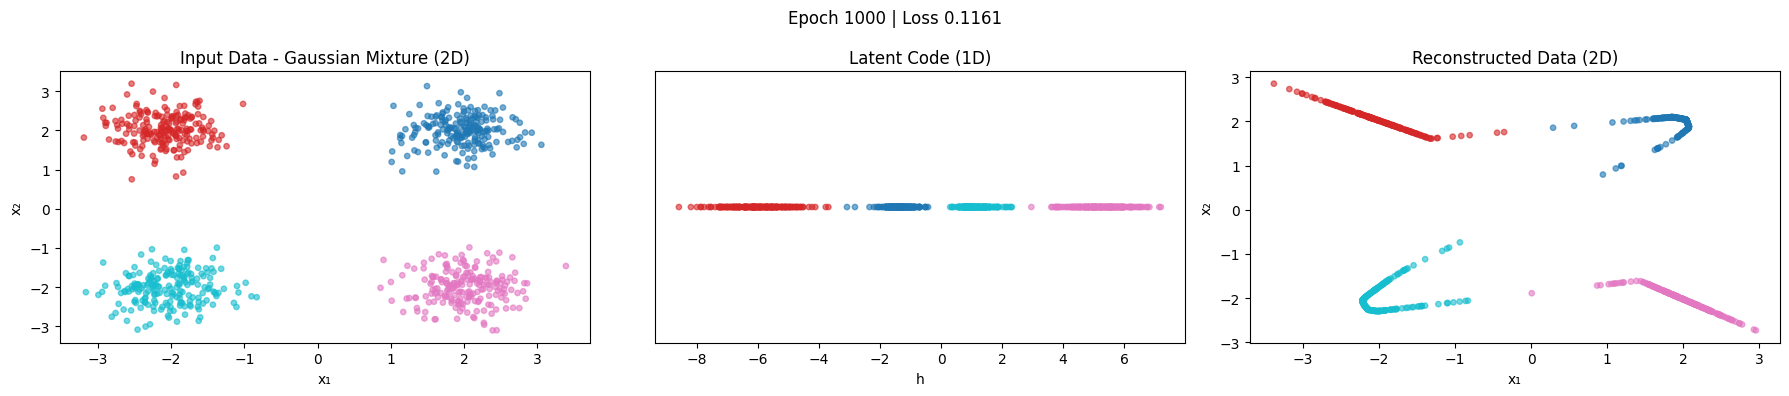

In [44]:
# Nonlinear, Undercomplete Autoencoder
#
# Compresses a 2D Gaussian mixture into a 1D (or 2D) latent code.
# Demonstrates the information bottleneck — what survives compression,
# what is lost, and how latent dimension controls the tradeoff.
#
# Loss: MSE (falls out of Gaussian decoder assumption)
# Data: 4-cluster 2D Gaussian mixture (800 samples)


class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        x_hat = self.decoder(h)
        return x_hat

    def encode(self, x):
        return self.encoder(x)
        
    def decode(self, h):
        return self.decoder(h)
        
# Reconstruction Loss Function -> MSE
def loss_fn(x, x_hat):
    # x: torch.Tensor, x_hat: torch.Tensor
    # -> torch.Tensor
    return ((x - x_hat) ** 2).mean()


# Input data - 2D Gaussian Mixture
means = torch.tensor([
    [ 2.0,  2.0],
    [-2.0,  2.0],
    [ 2.0, -2.0],
    [-2.0, -2.0]
])

n_per_cluster = 200
sigma = 0.4

data, labels = [], []
for k, mean in enumerate(means):
    samples = mean + sigma * torch.randn(n_per_cluster, 2)
    data.append(samples)
    labels.append(torch.full((n_per_cluster,), k))

x_data = torch.cat(data) # shape: (800, 2)
y_labels = torch.cat(labels) # shape: (800,) - only for plotting

input_dim = x_data.shape[1]
hidden_dim = 32
latent_dim = 1

# Set device usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move data to device
x_data = x_data.to(device)

# Initialize model
print(f"Autoencoder | input={input_dim}  hidden={hidden_dim}  latent={latent_dim}")
model = Autoencoder(input_dim, hidden_dim, latent_dim).to(device)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# Train
epochs = 1000
for i in range(1, epochs+1):
    model.train()
    optimizer.zero_grad()         # clear gradients from last step
    x_hat = model(x_data)         # forward pass (encode + decode)
    loss = loss_fn(x_data, x_hat) # compute loss (mse)
    loss.backward()               # backprop (autograd, fills .grad on all parameters)
    optimizer.step()              # update parameters (gradient descent)

    # Visual
    if i % 200 == 0 or i == 1:
        model.eval()
        with torch.no_grad():
            h = model.encode(x_data)
            x_hat = model.decode(h)

        h_np = h.cpu().numpy() 
        y_np = y_labels.cpu().numpy() 
        x_hat_np = x_hat.cpu().detach().numpy()

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))        
        fig.suptitle(f"Epoch {i} | Loss {loss.item():.4f}")

        axes[0].scatter(x_data.cpu()[:, 0], x_data.cpu()[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
        axes[0].set_title("Input Data - Gaussian Mixture (2D)")
        axes[0].set_xlabel("x₁")
        axes[0].set_ylabel("x₂")

        if latent_dim <= 1:
            axes[1].scatter(h_np, np.zeros_like(h_np), c=y_np, cmap='tab10', alpha=0.6, s=15)
            axes[1].set_title("Latent Code (1D)")
            axes[1].set_xlabel("h")
            axes[1].set_yticks([])
        else:
            axes[1].scatter(h_np[:, 0], h_np[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
            axes[1].set_title("Latent Code (2D)")
            axes[1].set_xlabel("h1")
            axes[1].set_ylabel("h2")

        axes[2].scatter(x_hat_np[:, 0], x_hat_np[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
        axes[2].set_title("Reconstructed Data (2D)")
        axes[2].set_xlabel("x₁")
        axes[2].set_ylabel("x₂")

        plt.tight_layout()
        plt.show()


In [138]:
# Sparse Autoencoder (Overcomplete + L1 Regularization)
#
# Overcomplete latent space (latent_dim > input_dim) with L1 sparsity penalty.
# Without regularization an overcomplete AE learns the identity — useless. 
# (we want to learn the distribution)
# L1 forces most latent activations toward zero, so each input is represented
# as a sparse combination of a large learned dictionary of features.
#
# Loss: MSE + lambda * L1(h)
# Data: 4-cluster 2D Gaussian mixture (800 samples)


"""
Rather than thinking of the sparsity penalty as a regularizer for the copying task,
we can think of the entire sparse autoencoder framework as approximating maximum likelihood training 
of a generative model that has latent variables
"""


class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        # encoder (in: input_dimx, input_dim)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        # decoder (in: hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        x_hat = self.decoder(h)
        return x_hat, h

    def encode(self, x): # -> h
        return self.encoder(x)
        
    def decode(self, h): # -> x_hat
        return self.decoder(h)

# Loss Function -> MSE(x,x_hat) + Sparsity_Penatly(h)
def loss_fn(x: torch.Tensor, x_hat: torch.Tensor, h: torch.Tensor, lam = 1e-2): 
    mse = ((x - x_hat) ** 2).mean()
    sp = lam * h.abs().mean()          # Lasso L1 Regularizer
    return mse + sp


# Input data - 2D Gaussian Mixture
# means = torch.tensor([
#     [ 2.0,  2.0],
#     [-2.0,  2.0],
#     [ 2.0, -2.0],
#     [-2.0, -2.0]
# ])

# n_per_cluster = 200
# sigma = 1.0 # Baseline: 0.4

# data, labels = [], []
# for k, mean in enumerate(means):
#     samples = mean + sigma * torch.randn(n_per_cluster, 2) # offset data points from N(0, 1) by mean + sigma
#     data.append(samples)
#     labels.append(torch.full((n_per_cluster,), k))

# x_data = torch.cat(data) # shape: (800, 2)
# y_labels = torch.cat(labels) # shape: (800,)


# Input Data - SKLearns Moon Clusters
x_data, y_labels = make_moons(n_samples=800, noise=0.1)
x_data, y_labels = torch.tensor(x_data, dtype=torch.float32), torch.tensor(y_labels, dtype=torch.float32)

input_dim = x_data.shape[1]
hidden_dim = 32  # FEEL FREE TO CHANGE (1 to inf)
latent_dim = 3 # FEEL FREE TO CHANGE (1 to inf)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device: ", device)

# Move data to device
x_data = x_data.to(device)

# Define Model
print(f"Autoencoder | input={input_dim}  hidden={hidden_dim}  latent={latent_dim}")
model = SparseAutoencoder(input_dim, hidden_dim, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# TRAINING

slider = widgets.FloatLogSlider(value=1e-1, min=-3, max=1, step=0.05, description='λ sparse')
button = widgets.Button(description='Run')
output = widgets.Output()

def on_click_train(b):
    output.clear_output()
    with output:
        lambda_sparse = slider.value
        print(f"Running with λ={lambda_sparse:.5f}")
        
        # TRAIN
        epochs = 500
        for i in range(1, epochs+1):
            model.train()
            optimizer.zero_grad()
        
            # Step
            x_hat, h = model(x_data) # Forward
            loss = loss_fn(x_data, x_hat, h, lambda_sparse) # Compute loss
            loss.backward() # Backprop
            optimizer.step() # Update parameters
        
            # Visual
            if i % 100 == 0 or i == 1:
                model.eval()
                with torch.no_grad():
                    h = model.encode(x_data)
                    x_hat = model.decode(h)
        
                h_np = h.cpu().numpy()        
                y_np = y_labels.cpu().numpy() 
                x_hat_np = x_hat.cpu().detach().numpy()
        
                fig, axes = plt.subplots(1, 3, figsize=(18, 4))        
                fig.suptitle(f"Epoch {i} | Loss {loss.item():.4f} | λ = {lambda_sparse}")
        
                axes[0].scatter(x_data.cpu()[:, 0], x_data.cpu()[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
                axes[0].set_title("Input Data - Gaussian Mixture (2D)")
                axes[0].set_xlabel("x₁")
                axes[0].set_ylabel("x₂")
        
                if latent_dim <= 1:
                    axes[1].scatter(h_np, np.zeros_like(h_np), c=y_np, cmap='tab10', alpha=0.6, s=15)
                    axes[1].set_title("Latent Code (1D)")
                    axes[1].set_xlabel("h")
                    axes[1].set_yticks([])
                else:
                    axes[1].scatter(h_np[:, 0], h_np[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
                    axes[1].set_title("Latent Code (First 2 Dimensions)")
                    axes[1].set_xlabel("h₁")
                    axes[1].set_ylabel("h₂")
        
                axes[2].scatter(x_hat_np[:, 0], x_hat_np[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
                axes[2].set_title("Reconstructed Data (2D)")
                axes[2].set_xlabel("x₁")
                axes[2].set_ylabel("x₂")
        
                plt.tight_layout()
                plt.show()


button.on_click(on_click_train)
display(slider, button, output)

using device:  cuda
Autoencoder | input=2  hidden=32  latent=3


FloatLogSlider(value=0.1, description='λ sparse', max=1.0, min=-3.0, step=0.05)

Button(description='Run', style=ButtonStyle())

Output()

In [142]:
# Denoising Autoencoder Example
# 
# As Goodfellow et al. describes, "Rather than adding a penalty Ω to the cost function, we can obtain an autoencoder 
# that learns something useful by changing the reconstruction error term of the cost function."
# where,
#         g(f(x)) is the error term in the loss function,
#                 L(x, g(f(x)))
# 
# In a DAE, we instead minimize
#         L(x, g(f(x_noise))),
# where x_noise is a copy of x that has been corrupted by some form of noise.
#
# "Denoising forces the DAE to implicitly learn p_data(x)"



class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        # encoder 
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

        # decoder 
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        x_hat = self.decoder(h)
        return x_hat, h

    def encode(self, x):
        return self.encoder(x)

    def decode(self, h):
        return self.decoder(h)

# Noise function
def add_noise(x, sigma=0.4):
    eps_noise = torch.randn_like(x) * sigma # random gaussian samples * intensity
    x_noise = x + eps_noise
    return x_noise 

# Loss function -> MSE(x, x_noise_hat)
def loss_fn(x, x_noise_hat):
    return ((x - x_noise_hat) ** 2).mean()



# Input data - 2D Gaussian Mixture
# - uncomment to use -
# means = torch.tensor([
#     [ 2.0,  2.0],
#     [-2.0,  2.0],
#     [ 2.0, -2.0],
#     [-2.0, -2.0]
# ])

# n_per_cluster = 200
# sigma = 1.5 # 0.4

# data, labels = [], []
# for k, mean in enumerate(means):
#     samples = mean + sigma * torch.randn(n_per_cluster, 2) # offset data points from N(0, 1) by mean + sigma
#     data.append(samples)
#     labels.append(torch.full((n_per_cluster,), k))

# x_data = torch.cat(data) # shape: (800, 2)
# y_labels = torch.cat(labels) # shape: (800,)

# - uncomment to use -
# Input Data - SKLearns Moon Clusters
# x_data, y_labels = make_moons(n_samples=800, noise=0.1)
# x_data, y_labels = torch.tensor(x_data, dtype=torch.float32), torch.tensor(y_labels, dtype=torch.float32)

# Input Data - 28x28 Pixel Number
x_data = torch.tensor([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
], dtype=torch.float32)


input_dim = x_data.shape[1]
hidden_dim = 32
latent_dim = 1


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device: ", device)

# Move data tensor to device
x_data.to(device)

# Define model
print(f"Autoencoder | input={input_dim}  hidden={hidden_dim}  latent={latent_dim}")
model = DenoisingAutoencoder(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# TRAINING

slider = widgets.FloatLogSlider(value=1e-1, min=-3, max=1, step=0.05, description='σ corruption')
button = widgets.Button(description='Run')
output = widgets.Output()

def on_click_train(b):
    output.clear_output()
    with output:
        sigma = slider.value
        print(f"Running with σ={sigma:.5f}")
        
        # TRAIN
        epochs = 2000
        for i in range(1, epochs+1):
            model.train()
            optimizer.zero_grad()
        
            x_noise = add_noise(x_data, sigma=sigma) # Corrupt input data
            
            x_noise_hat, h = model(x_noise) # Forward
            loss = loss_fn(x_data, x_noise_hat) # Compute loss
            loss.backward() # Backprop
            optimizer.step() # Update parameters
        
            # Visual
            if i % 200 == 0 or i == 1:
                model.eval()
                with torch.no_grad():
                    x_noise = add_noise(x_data, sigma=sigma)
                    x_hat, h = model(x_noise)
                
                fig, axes = plt.subplots(1, 3, figsize=(10, 4))
                
                axes[0].imshow(x_data.cpu(), cmap='gray')
                axes[0].set_title("Clean")
                axes[0].axis('off')
                
                axes[1].imshow(x_noise.cpu(), cmap='gray')
                axes[1].set_title(f"Corrupted (σ={sigma})")
                axes[1].axis('off')
                
                axes[2].imshow(x_hat.cpu(), cmap='gray')
                axes[2].set_title("Reconstructed")
                axes[2].axis('off')
                
                plt.tight_layout()
                plt.show()
                
                # - uncomment when using 2D Gaussian Mixture or Make Moons input data (x_data) -
                # model.eval()
                # with torch.no_grad():        
                #     x_noise = add_noise(x_data, sigma=sigma) 
                #     h = model.encode(x_noise)
                #     x_hat = model.decode(h)
        
                # h_np = h.cpu().numpy()        
                # y_np = y_labels.cpu().numpy()
                # x_hat_np = x_hat.cpu().detach().numpy()
        
                # fig, axes = plt.subplots(1, 3, figsize=(18, 4))        
                # fig.suptitle(f"Epoch {i} | Loss {loss.item():.4f}")
        
                # axes[0].scatter(x_noise.cpu()[:, 0], x_noise.cpu()[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
                # axes[0].set_title("Input Data - Gaussian Mixture (2D)")
                # axes[0].set_xlabel("x₁")
                # axes[0].set_ylabel("x₂")
        
                # if latent_dim <= 1:
                #     axes[1].scatter(h_np, np.zeros_like(h_np), c=y_np, cmap='tab10', alpha=0.6, s=15)
                #     axes[1].set_title("Latent Code (1D)")
                #     axes[1].set_xlabel("h")
                #     axes[1].set_yticks([])
                # else:
                #     axes[1].scatter(h_np[:, 0], h_np[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
                #     axes[1].set_title("Latent Code (First 2 Dimensions)")
                #     axes[1].set_xlabel("h₁")
                #     axes[1].set_ylabel("h₂")
        
                # axes[2].scatter(x_hat_np[:, 0], x_hat_np[:, 1], c=y_np, cmap='tab10', alpha=0.6, s=15)
                # axes[2].set_title("Reconstructed Data (2D)")
                # axes[2].set_xlabel("x₁")
                # axes[2].set_ylabel("x₂")
        
                # plt.tight_layout()
                # plt.show() 

button.on_click(on_click_train)
display(slider, button, output)

using device:  cuda
Autoencoder | input=28  hidden=32  latent=1


FloatLogSlider(value=0.1, description='σ corruption', max=1.0, min=-3.0, step=0.05)

Button(description='Run', style=ButtonStyle())

Output()

### **Latent Space Analysis**

**What we will analyze:**
- Interpolation between latent codes
- The 'Holes' problem
- Bottleneck dim sweep

**Optional:**
- PCA of latent codes vs input data
- Activation analysis of sparse AE


x0:  [0.24869299 4.9874544 ]
x1:  [-2.4543784  0.6815748]
Autoencoder | input=2  hidden=32  latent=1


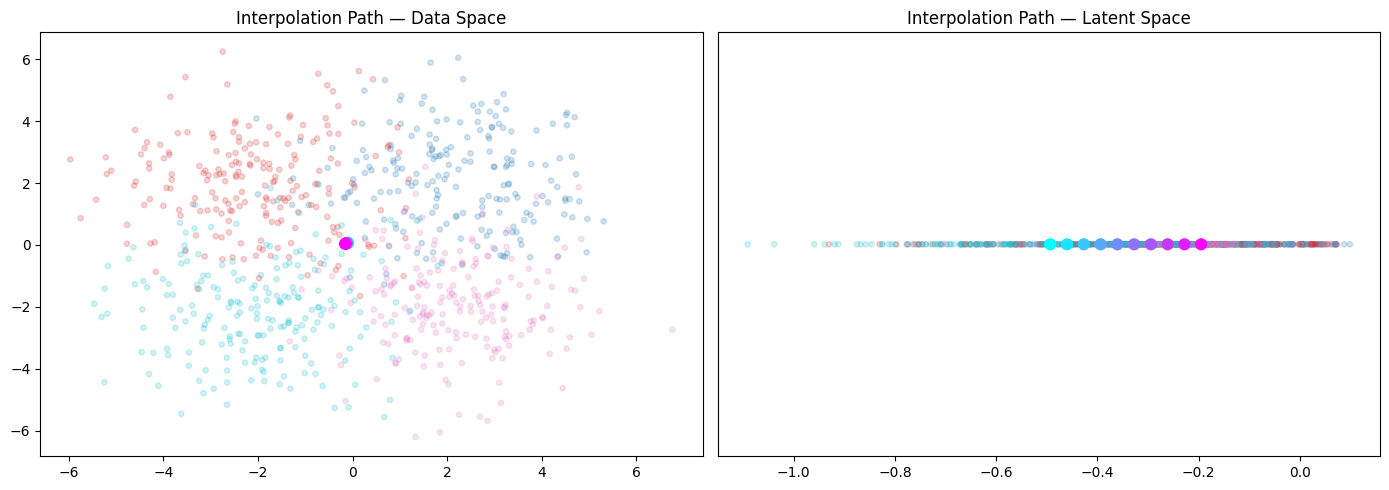

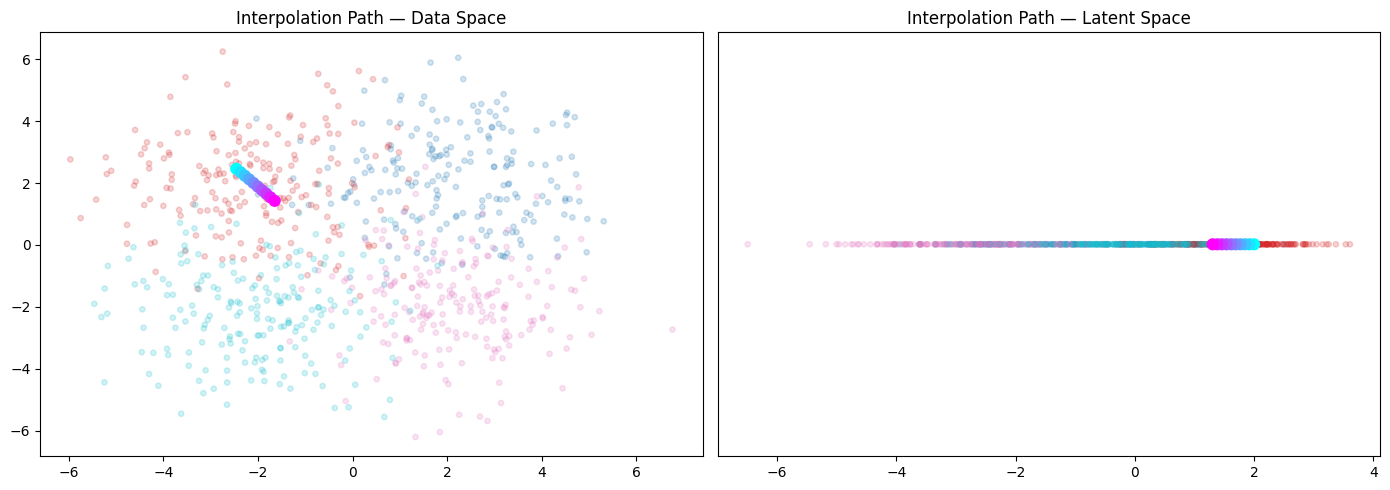

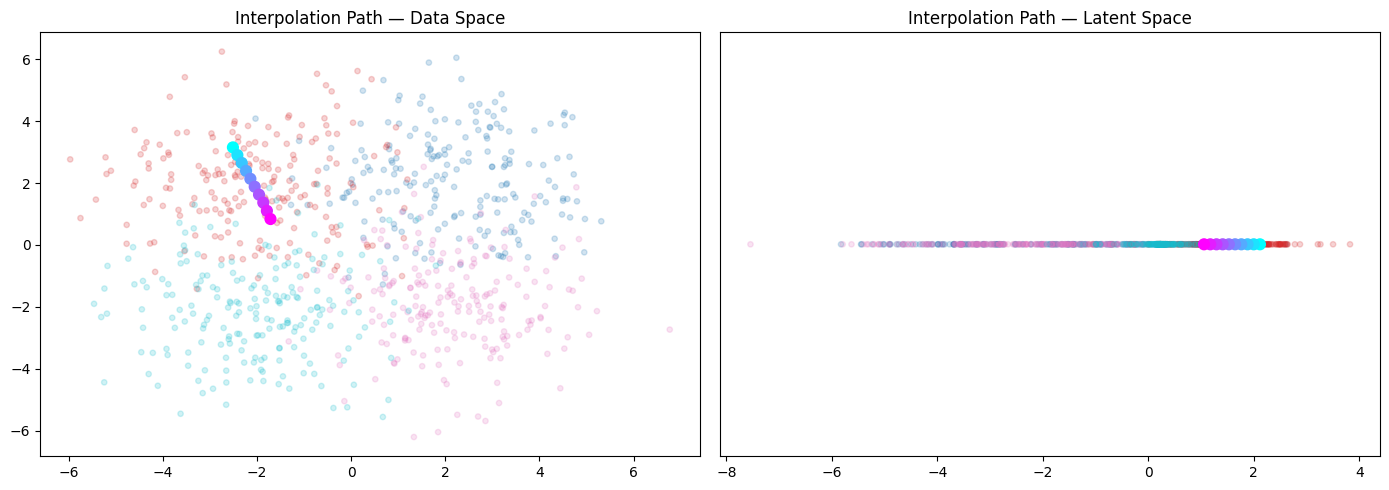

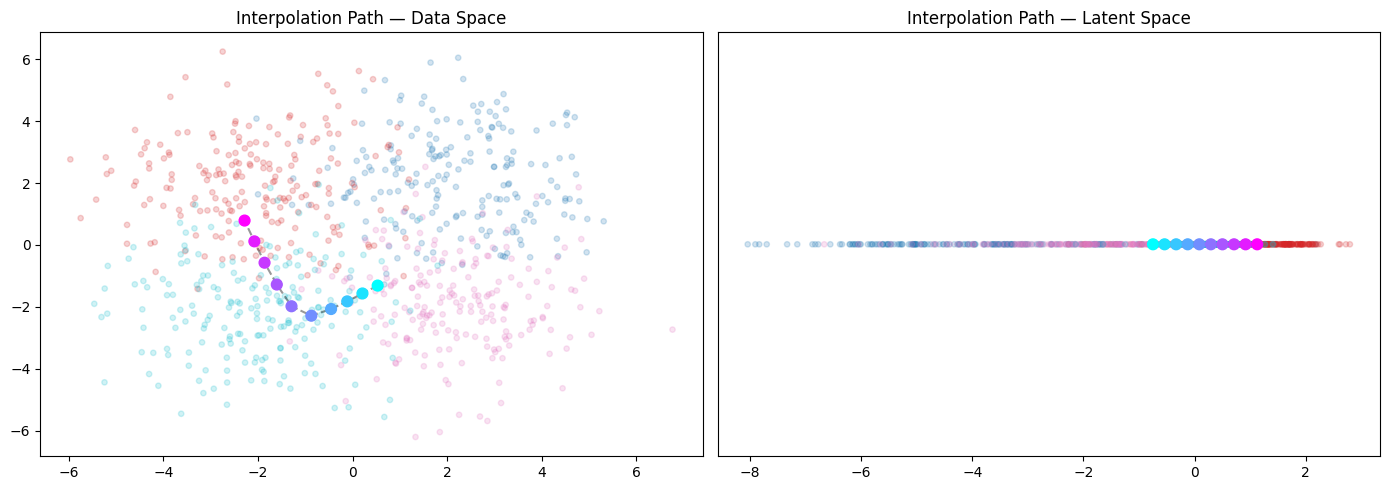

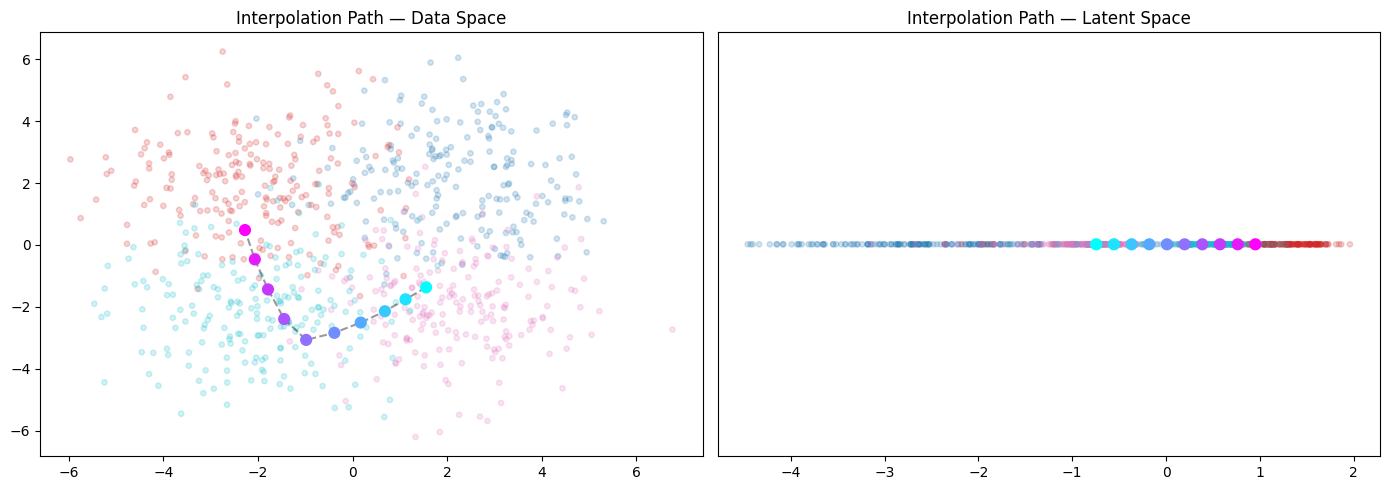

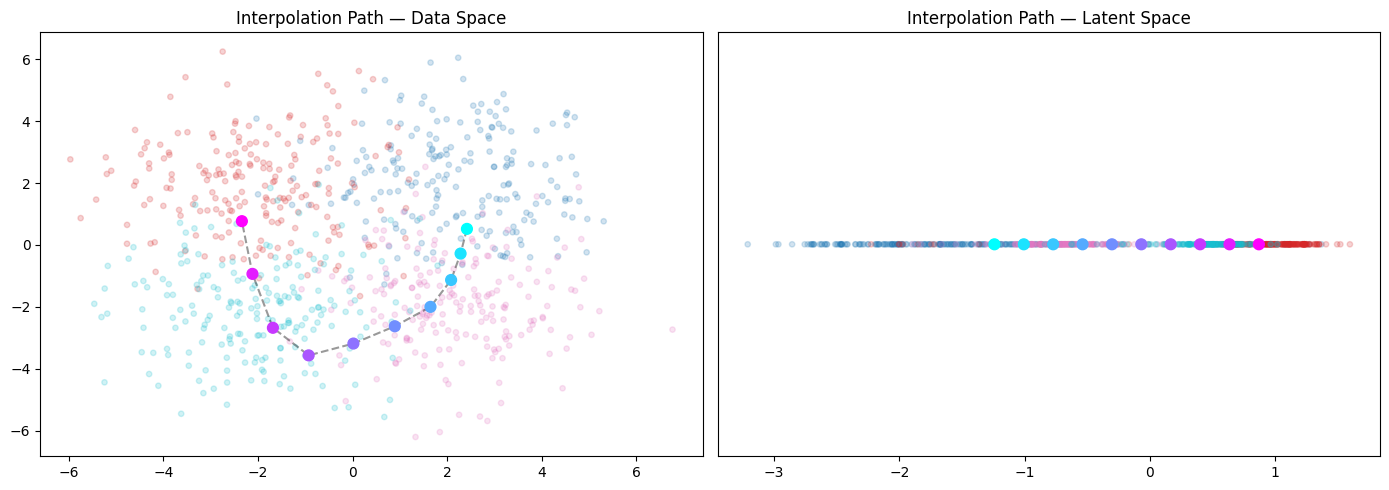

In [150]:
# Latent Space Analysis - Interpolation (Undercomplete AE)
#

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        x_hat = self.decoder(h)
        return x_hat

    def encode(self, x):
        return self.encoder(x)
        
    def decode(self, h):
        return self.decoder(h)


# Input data - 2D Gaussian Mixture
means = torch.tensor([
    [ 2.0,  2.0],
    [-2.0,  2.0],
    [ 2.0, -2.0],
    [-2.0, -2.0]
])

n_per_cluster = 200
sigma = 1.5 # 0.4

data, labels = [], []
for k, mean in enumerate(means):
    samples = mean + sigma * torch.randn(n_per_cluster, 2) # offset data points from N(0, 1) by mean + sigma
    data.append(samples)
    labels.append(torch.full((n_per_cluster,), k))

x_data = torch.cat(data) # shape: (800, 2)
y_labels = torch.cat(labels) # shape: (800,)

# x_data, y_labels = make_moons(n_samples=800, noise=0.1)
# x_data, y_labels = torch.tensor(x_data, dtype=torch.float32), torch.tensor(y_labels, dtype=torch.float32)

# For this cell, we will keep the data on the CPU

input_dim = x_data.shape[1] # 2
hidden_dim = 32
latent_dim = 1


# Choose two data points from two different clusters (for Interpolation)
x0 = x_data[random.randint(0, 199)]
x1 = x_data[random.randint(600,799)]

print("x0: ", x0.numpy())
print("x1: ", x1.numpy())

# Note that we are working with known, labeled data, so we are able to choose from a range of points we know to be one of the clusters
# if this were unknown we could use a technique like KMeans to cluster the data ourselves and sample from that.


# Define model
print(f"Autoencoder | input={input_dim}  hidden={hidden_dim}  latent={latent_dim}")
model = Autoencoder(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train
epochs = 1000
for i in range(1, epochs+1):
    model.train()
    optimizer.zero_grad()         # clear gradients from last step
    x_hat = model(x_data)         # forward pass (encode + decode)
    loss = loss_fn(x_data, x_hat) # compute loss (mse)
    loss.backward()               # backprop (autograd, fills .grad on all parameters)
    optimizer.step()              # update parameters (gradient descent)

    # Visual
    if i % 200 == 0 or i == 1:
        model.eval()
        with torch.no_grad():
            h = model.encode(x_data)
            x_hat = model.decode(h)

        h_np = h.numpy() 
        y_np = y_labels.numpy() 
        x_hat_np = x_hat.numpy()

        # Encode them as two separate latent codes
        with torch.no_grad():
            h0 = model.encode(x0.unsqueeze(0))
            h1 = model.encode(x1.unsqueeze(0))
         
        # The Interpolation (Intuition)
        # Generate a sequence of latent codes that smoothly walk from h0 to h1:
        #     ht = (1 - t) * h0 + t * h1,  t ∈ [0, 1]
        # At t = 0,
        #     you are at h0
        # At t = 1,
        #     you are at h1
        # Everything in between [t1, t2, ..., tk] is a weighted blend.
        #
        # Possible outcome: decoder learns 1D manifold
        
        # INTERPOLATION
        steps = 10
        ts = torch.linspace(0, 1, steps) # [0.0, 0.11, 0.22, ..., 1.0] (time steps)

        # Form interp path
        interpolated = []
        for t in ts:
            ht = (1 - t) * h0 + t * h1
            interpolated.append(ht)
        
        interpolated = torch.cat(interpolated) # shape (steps, latent_dim)
        
        # Decode the path
        with torch.no_grad():
            x_path = model.decode(interpolated)   # shape (steps, 2)
        x_path_np = x_path.numpy()
        
        # Visual
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # left — data space path
        axes[0].scatter(x_data[:, 0], x_data[:, 1], 
                        c=y_labels.numpy(), cmap='tab10', alpha=0.2, s=15)
        axes[0].scatter(x_path_np[:, 0], x_path_np[:, 1], 
                        c=ts.numpy(), cmap='cool', s=60, zorder=5)
        axes[0].plot(x_path_np[:, 0], x_path_np[:, 1], 'k--', alpha=0.4)
        axes[0].set_title("Interpolation Path — Data Space")
        
        # right — latent space path
        interp_np = interpolated.numpy()
        axes[1].scatter(h_np.flatten(), np.zeros(len(h_np)), 
                        c=y_labels.numpy(), cmap='tab10', alpha=0.2, s=15)
        axes[1].scatter(interp_np.flatten(), np.zeros(steps), 
                        c=ts.numpy(), cmap='cool', s=60, zorder=5)
        axes[1].set_title("Interpolation Path — Latent Space")
        axes[1].set_yticks([])
        
        plt.tight_layout()
        plt.show()

## **Variational Autoencoders**




In [ ]:
# Variational Autoencoder Example
